# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import matplotlib.pyplot as plt

/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.jetbrains.pycharm.1003326.4172874", R: "0"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpCFh0bV", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpbmlRSP"
  warnings.warn(


# Loading and Determining Population

In [3]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['swiss', 'RegularPop1000', 'cluster', 'meuse', 'random', 'grid', 'AggregatedPop1027'])
dict_keys(['swiss', 'RegularPop1000', 'cluster', 'meuse', 'random', 'grid', 'AggregatedPop1027'])
dict_keys(['equal', 'unequal'])


In [4]:
n = 50
pop_str = 'meuse'
prob_str = 'unequal'
coords = coords_dict[pop_str]
probs = probs_dict[pop_str][prob_str]
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

In [21]:
coords = np.loadtxt("populations/AggregatedPop1027_2d.csv", delimiter=",", skiprows=0)
# coords = np.loadtxt("populations/RegularPop1000_2d.csv", delimiter=",", skiprows=0)
rng = gs.random.rng()
n = 200
probs = rng.equal_probabilities(n, coords.shape[0])
pop = gs.Population(coords, probs)

In [ ]:
rng = gs.random.rng()
# grid_size = 5
# N = grid_size ** 2
N = 400
n = 8
coords = rng.random_coordinates((N, 2))
probs = rng.unequal_probabilities(n, N)
pop = gs.Population(coords, probs)

# Test

In [ ]:
ks = gs.sampling.KMeansSampler(
    population=pop,
    n=n,
    n_zones=(1, 1),
    zone_builder='sweep',
    units_order='spiral',
    zones_order='spiral',
    split_size=0.01
)

In [ ]:
for cluster in ks.clusters:
    print(cluster.get_total_prob_stats(True))
    print()

In [ ]:
for cluster in ks.clusters:
    if len(cluster.zones) == 0:
        print(cluster.get_total_prob_stats(False))
        print(cluster.get_index_share())
        print()

In [ ]:
ax = gs.plot(pop, ks.clusters)

In [ ]:
np.mean(ks.fips - modified_probs)

In [ ]:
np.sum(ks.all_samples_probs)

In [ ]:
ks.score_summary_df()

In [ ]:
ks.reorder_change(1, 1, 1, 1, 1)

In [ ]:
abk = gs.clustering.AuxiliaryBalancedKMeans(k=4, split_size=0.001)
abk.fit(pop)

In [ ]:
abk = gs.clustering.NestedUPBalancedKMeans(k=n, split_size=0.001)
abk.fit(pop)

In [ ]:
for id_, cluster in abk.clusters.items():
    print(f'\nCluster {id_}:')
    print('floor index:', cluster['border']['floor_index'])
    print('floor pct:', cluster['border']['floor_percentage'])
    print('ceil index:', cluster['border']['ceil_index'])
    print('ceil pct:', cluster['border']['ceil_percentage'])
    total = np.sum(probs[cluster['free']])
    # print(f'free sum: {total}')
    if cluster['border']['floor_index'] != -1:
        total += probs[cluster['border']['floor_index']] * cluster['border']['floor_percentage']
    if cluster['border']['ceil_index'] != -1:
        total += probs[cluster['border']['ceil_index']] * cluster['border']['ceil_percentage']
    print(f'total sum: {round(total, 5)}')

In [ ]:
for i in range(n):
    print(f"Total prob label {i}: {round(np.sum(pop.probs[abk.labels == i]), 4)}")

In [ ]:
abk.centroids

In [ ]:
abk.labels

In [ ]:
gs.clustering.shortest_through_all_points(abk.centroids)

In [ ]:
plt.scatter(*coords.T, c=abk.labels)
plt.scatter(*abk.centroids.T, c='black', s=100)

In [ ]:
np.vstack([np.array([1, 2]), np.array([2, 3])])

In [ ]:
ks = gs.sampling.KMeansSampler(
    population=pop,
    n=n,
    n_clusters=2,
    # cluster_in_cluster=True,
    n_zones=(1, 1),
    zone_builder='sweep',
    units_order='spiral',
    zones_order='spiral',
    split_size=0.001
)

In [ ]:
ks.reorder('lexico-xy', 'lexico-xy')

In [ ]:
ks.all_samples.shape

In [ ]:
np.sum(ks.all_samples_probs)

In [ ]:
for sample_obj in ks.design:
    if len(sample_obj.ids) < ks.n and sample_obj.probability > 1e-9:
        print(list(sample_obj.ids), sample_obj.probability)

In [ ]:
for cluster in ks.clusters:
    print(cluster.zones[0].index_share)

In [ ]:
ax = gs.plot(pop, ks.clusters, connect_points=False)
ax.scatter(*pop.coords[ks.all_samples[5]].T, c='black', s=100, zorder=10)

In [ ]:
for cluster in ks.clusters:
    cluster_index_share = cluster.get_index_share()
    print(f'\ncluster prob sum: {np.sum(pop.probs[cluster_index_share[:, 0].astype(int)]*cluster_index_share[:, 1])}')
    for zone in cluster.zones:
        print(f'zone prob sum: {np.sum(zone.prob)}')

In [ ]:
samples = ks.sample(10)
ax = gs.plot(pop, ks.clusters, connect_points=False)
ax.scatter(*pop.coords[samples[0]].T, c='black', s=100, zorder=10)

# Building Initial Designs

In [22]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]
n_zones_sweep = [(1, 1)]
n_zones_cluster = [4, 6]
combinations = list(itertools.product(['sweep'], n_zones_sweep, orders, orders)) #+ list(itertools.product(['cluster'], n_zones_cluster, orders, orders))

In [24]:
initial_designs = []
num_trials = 1
for zone_builder, n_zones, units_order, zones_order in tqdm(combinations, desc="Generating initial designs", total=len(combinations), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n = n,
            n_zones=n_zones,
            zone_builder=zone_builder,
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.1
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))

Generating initial designs:   0%|          | 0/1 [00:00<?, ?orders/s]/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpbmlRSP", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpwCUzO3"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpbmlRSP", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpUfgawD"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" re

# Run

In [25]:
moran_criteria = gs.criteria.MoranCriteria()

In [26]:
initial_criteria_value = np.array([moran_criteria(design) for design in initial_designs])
best_design = initial_designs[np.argmax(initial_criteria_value)]
best_criteria_value = np.min(initial_criteria_value)
best_criteria_value

np.float64(-0.4052058666143574)

In [27]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.4052058666143574


In [ ]:
astar = gs.search.AStar(
    [astar.best_design],
    moran_criteria
)

In [28]:
astar.run(
    max_iterations = 1000,
    num_new_nodes = 20,
    max_open_set_size = 1000,

    n_clusters_to_change_order_zone = 1,
    n_changes_in_order_of_zones = 1,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


parent node: -0.4052058666143574


R callback write-console: 
  
R callback write-console: 
  


KeyboardInterrupt: 

In [29]:
astar.best_criteria_value

np.float64(-0.4052058666143574)

In [30]:
astar.best_design.kmeans.all_samples.shape

(1027, 200)

In [31]:
np.sum(astar.best_design.kmeans.all_samples_probs)

np.float64(1.0000000000929998)

In [33]:
np.mean(np.abs(astar.best_design.kmeans.fips - probs))

np.float64(1.811116062920931e-11)

In [ ]:
astar.best_design.kmeans.fips

In [34]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.006586,0.008994
moran,-0.405206,0.036495
local_balance,0.052312,0.004582
voronoi,0.178269,0.030251


In [18]:
for cluster in astar.best_design.kmeans.clusters:
    cluster_index_share = cluster.get_index_share()
    print(f'\ncluster prob sum: {np.sum(pop.probs[cluster_index_share[:, 0].astype(int)]*cluster_index_share[:, 1])}')
    for zone in cluster.zones:
        print(f'zone prob sum: {np.sum(zone.prob)}')


cluster prob sum: 1.0
zone prob sum: 0.3842509393889886

cluster prob sum: 1.0
zone prob sum: 0.7925175624897892

cluster prob sum: 1.0

cluster prob sum: 1.0000000000000002
zone prob sum: 0.2481620650220552

cluster prob sum: 1.0
zone prob sum: 0.6884495997386046

cluster prob sum: 1.0000000000000007
zone prob sum: 0.5923868648913575

cluster prob sum: 1.0000000000000002
zone prob sum: 0.7444861950661655

cluster prob sum: 1.0
zone prob sum: 0.3922561672929259

cluster prob sum: 1.0000000000000004
zone prob sum: 0.7444861950661654

cluster prob sum: 1.0
zone prob sum: 0.9446168926645971

cluster prob sum: 0.999999999999999
zone prob sum: 0.6003920927952947

cluster prob sum: 1.0
zone prob sum: 0.6804443718346675

cluster prob sum: 1.0000000000000016
zone prob sum: 0.8245384741055383

cluster prob sum: 0.9999999999999998

cluster prob sum: 0.9999999999999984
zone prob sum: 0.5363502695637967

cluster prob sum: 1.0000000000000004

cluster prob sum: 0.9999999999999996
zone prob sum: 0.7

In [19]:
for cluster in astar.best_design.kmeans.clusters:
    if len(cluster.zones) == 0:
        print(cluster.get_total_prob_stats(False))
        print(cluster.get_index_share())
        print()

Total Prob in Cluster: 1.0
[[0.         0.74309724]
 [1.         0.76240867]]

Total Prob in Cluster: 1.0
[[20.          0.62379669]
 [19.          0.96691729]]

Total Prob in Cluster: 1.0
[[38.          0.28862974]
 [39.          0.95086924]]

Total Prob in Cluster: 1.0
[[52.          0.92435876]
 [58.          0.10498866]]

Total Prob in Cluster: 1.0
[[53.          0.9113902 ]
 [54.          0.17582418]]

Total Prob in Cluster: 1.0
[[60.          0.75588697]
 [61.          0.85661277]]

Total Prob in Cluster: 1.0
[[64.          0.79563492]
 [65.          0.90176871]]

Total Prob in Cluster: 1.0
[[79.          0.84786642]
 [78.          0.73979592]]



<Axes: xlabel='X', ylabel='Y'>

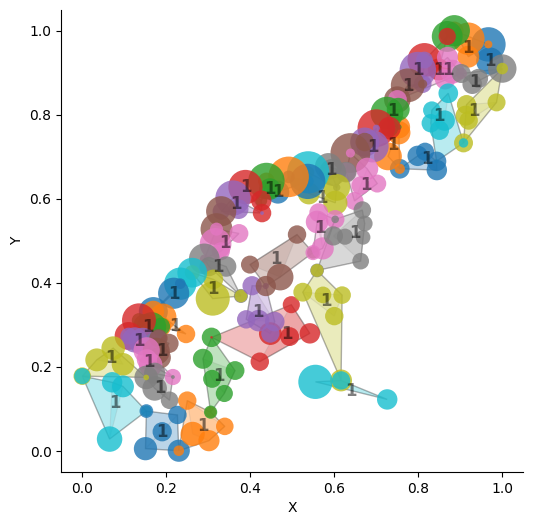

In [20]:
gs.plot(pop, astar.best_design.kmeans.clusters, connect_points=False)

In [ ]:
x